# BESOIN 4 : MODÈLE DE PRÉDICTION DE LA PUISSANCE NOMINALE

## Objectif
Développer un modèle d'intelligence artificielle capable de **prédire la catégorie de puissance nominale** d'une borne de recharge électrique (IRVE).

### Justification de l'approche par classification
La puissance nominale est une valeur continue, mais en pratique les bornes IRVE sont commercialisées selon des **paliers normalisés** (7.4 kW, 22 kW, 50 kW, etc.). On transforme donc ce problème en **classification multi-classes** selon les catégories officielles :
- **Lente** : ≤ 7.4 kW (bornes domestiques, prises EF/Type2 basiques)
- **Normale** : 7.4 – 22 kW (bornes AC résidentielles/parkings)
- **Accélérée** : 22 – 50 kW (bornes semi-rapides)
- **Rapide** : 50 – 150 kW (bornes DC rapides)
- **Ultra-rapide** : > 150 kW (stations haute puissance, CCS/CHAdeMO)

# 1. Importation des bibliothèques et configuration

Import des bibliothèques nécessaires :
- `pandas` / `numpy` : manipulation des données
- `joblib` : sérialisation des modèles, encodeurs et scaler entraînés
- `matplotlib` / `seaborn` : visualisations statiques
- `scikit-learn` : `train_test_split`, `GridSearchCV`, `StandardScaler`, `LabelEncoder`, les 4 algorithmes comparés et les métriques d'évaluation

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import os
os.makedirs('output', exist_ok=True)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

print('Bibliothèques chargées avec succès.')

Bibliothèques chargées avec succès.


# 2. Chargement et préparation des données

In [2]:
df = pd.read_csv('export_IA.csv', low_memory=False)
print(f'Dimensions du dataset : {df.shape}')
print(f'\nColonnes disponibles :\n{list(df.columns)}')

Dimensions du dataset : (138934, 47)

Colonnes disponibles :
['id_pdc', 'id_station', 'id_station_local', 'id_pdc_local', 'nom_station', 'nom_amenageur', 'siren_amenageur', 'contact_amenageur', 'operateur', 'contact_operateur', 'telephone_operateur', 'enseigne', 'code_pays_operateur', 'code_operateur', 'adresse', 'code_insee', 'commune', 'code_postal', 'longitude', 'latitude', 'implantation', 'nb_pdc', 'puissance', 'prise_ef', 'prise_type2', 'prise_ccs', 'prise_chademo', 'prise_autre', 'pmr', 'restriction_gabarit', 'deux_roues', 'raccordement', 'num_pdl', 'cable_t2_attache', 'type_tarif', 'prix_kwh_norm', 'prix_min_norm', 'gratuit', 'paiement_acte', 'paiement_cb', 'paiement_autre', 'tarification_brute', 'condition_acces', 'reservation', 'horaires', 'date_service', 'date_maj']


## 2.1 Création de la variable cible

On discrétise la puissance nominale en 5 catégories selon les standards industriels IRVE.

In [3]:
def categoriser_puissance(p):
    """Catégorise la puissance nominale selon les paliers standards IRVE."""
    if p <= 7.4:
        return 'Lente (<= 7.4 kW)'
    elif p <= 22:
        return 'Normale (7.4 - 22 kW)'
    elif p <= 50:
        return 'Acceleree (22 - 50 kW)'
    elif p <= 150:
        return 'Rapide (50 - 150 kW)'
    else:
        return 'Ultra-rapide (> 150 kW)'

TARGET = 'puissance_categorie'
df[TARGET] = df['puissance'].apply(categoriser_puissance)

ORDRE = [
    'Lente (<= 7.4 kW)',
    'Normale (7.4 - 22 kW)',
    'Acceleree (22 - 50 kW)',
    'Rapide (50 - 150 kW)',
    'Ultra-rapide (> 150 kW)'
]

print('Distribution de la cible :')
dist = df[TARGET].value_counts().reindex(ORDRE)
print(dist)
print(f'\nTotal : {dist.sum()} bornes')

Distribution de la cible :
puissance_categorie
Lente (<= 7.4 kW)          26856
Normale (7.4 - 22 kW)      61791
Acceleree (22 - 50 kW)     18683
Rapide (50 - 150 kW)       13638
Ultra-rapide (> 150 kW)    17966
Name: count, dtype: int64

Total : 138934 bornes


## 2.2 Sélection et justification des features

**Variables retenues :** `implantation`, `nb_pdc`, `prise_ccs`, `prise_chademo`, `prise_type2`, `prise_ef`, `gratuit`, `condition_acces`.

**Justification du choix des variables :**
- `implantation` : le type de lieu (station dédiée, parking, voirie) conditionne fortement la puissance installée.
- `nb_pdc` : les stations avec plus de points de charge tendent à avoir des puissances plus élevées.
- `prise_ccs` : prise exclusivement utilisée pour la charge rapide DC (≥ 50 kW).
- `prise_chademo` : autre standard DC rapide, corrélé aux fortes puissances.
- `prise_type2` : couvre les charges lentes à accélérées (AC).
- `prise_ef` : prise domestique limitée à ~3 kW, donc indicateur de charge lente.
- `gratuit` : les bornes gratuites sont souvent des bornes lentes en voirie ou parkings publics.
- `condition_acces` : accès réservé/libre influence le type d'infrastructure déployée.

In [4]:
FEATURES = ['implantation', 'nb_pdc', 'prise_ccs', 'prise_chademo',
            'prise_type2', 'prise_ef', 'gratuit', 'condition_acces']

data = df[FEATURES + [TARGET]].copy()
data = data.dropna(subset=[TARGET])
print(f'Shape après filtre cible : {data.shape}')

Shape après filtre cible : (138934, 9)


## 2.3 Nettoyage, Imputation et Encodage des données

**Justification du choix des transformations :**
- Encodage manuel des booléens (`prise_ccs`, `prise_chademo`, `prise_type2`, `prise_ef`, `gratuit`) : le CSV mélange plusieurs formats (`True`/`False`, `TRUE`/`FALSE`), un mapping explicite évite de dépendre du typage implicite de pandas.
- `LabelEncoder` pour `implantation` et `condition_acces` : variables catégorielles à faible cardinalité, converties en entiers pour les algorithmes utilisés. Les encodeurs sont sauvegardés (`joblib`) pour appliquer exactement la même transformation aux nouvelles données dans `main.py`.
- Imputation de `nb_pdc` par la médiane : plus robuste aux valeurs extrêmes que la moyenne, et évite de perdre des lignes pour une seule valeur manquante.

In [5]:
bool_cols = ['prise_ccs', 'prise_chademo', 'prise_type2', 'prise_ef', 'gratuit']
for col in bool_cols:
    data[col] = data[col].map({
        True: 1, False: 0,
        'True': 1, 'False': 0,
        'TRUE': 1, 'FALSE': 0
    }).fillna(0).astype(int)

data['implantation'] = data['implantation'].fillna('inconnu')
le_implantation = LabelEncoder()
data['implantation'] = le_implantation.fit_transform(data['implantation'])
joblib.dump(le_implantation, 'le_implantation_b4.pkl')
print(f'Classes implantation ({len(le_implantation.classes_)}) : {list(le_implantation.classes_)}')

data['condition_acces'] = data['condition_acces'].str.strip().fillna('inconnu')
le_acces = LabelEncoder()
data['condition_acces'] = le_acces.fit_transform(data['condition_acces'])
joblib.dump(le_acces, 'le_acces_b4.pkl')
print(f'Classes condition_acces ({len(le_acces.classes_)}) : {list(le_acces.classes_)}')

mediane_pdc = data['nb_pdc'].median()
data['nb_pdc'] = data['nb_pdc'].fillna(mediane_pdc)
print(f'\nValeurs manquantes restantes :\n{data[FEATURES].isnull().sum()}')

Classes implantation (5) : ['Parking privé réservé à la clientèle', 'Parking privé à usage public', 'Parking public', 'Station dédiée à la recharge rapide', 'Voirie']
Classes condition_acces (5) : ['Acc\x8fs libre', 'Acc¸s libre', 'Accès libre', 'Accès réservé', 'AccĂ¨s libre']

Valeurs manquantes restantes :
implantation       0
nb_pdc             0
prise_ccs          0
prise_chademo      0
prise_type2        0
prise_ef           0
gratuit            0
condition_acces    0
dtype: int64


# 3. Analyse Exploratoire des Données

**Justification du choix des graphiques :**
- **Distribution des catégories de puissance** : vérifie l'équilibre des classes avant l'entraînement — un fort déséquilibre annonce des difficultés de prédiction sur les classes minoritaires.
- **Proportion des types de prises par catégorie** : valide que chaque feature de prise discrimine bien les catégories de puissance avant de les utiliser comme variables d'entrée.
- **Heatmap de corrélation des features** : détecte une éventuelle multicolinéarité qui pénaliserait les modèles linéaires.
- **Distribution de `nb_pdc` par catégorie** : vérifie que cette variable numérique varie effectivement selon la catégorie de puissance, justifiant son inclusion.

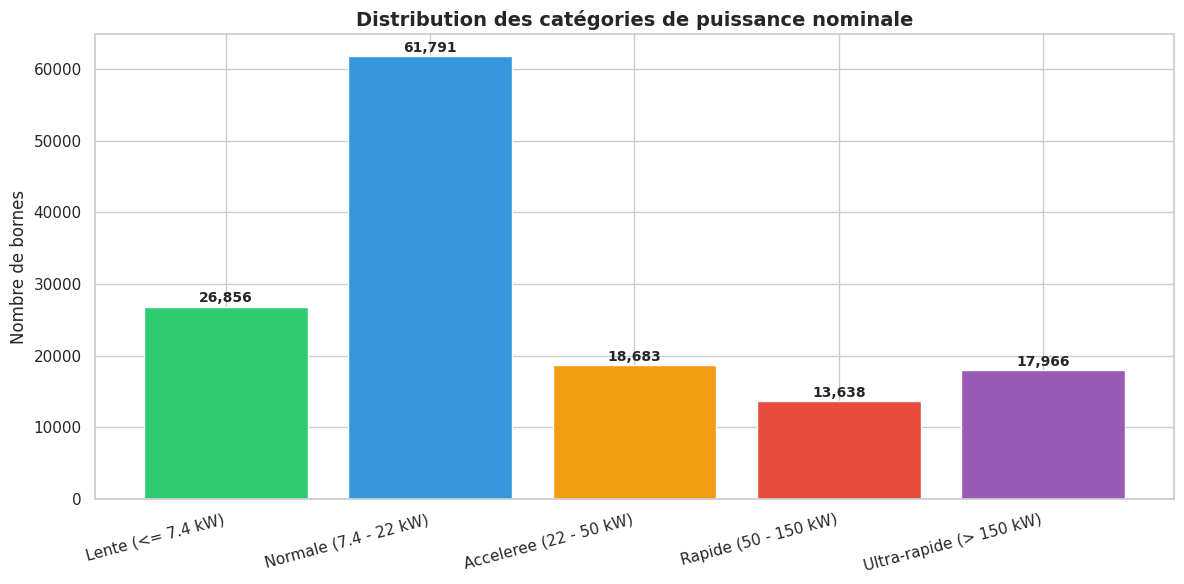

Observation : La classe "Normale" domine (déséquilibre de classes).


In [6]:
plt.figure(figsize=(12, 6))
counts = data[TARGET].value_counts().reindex(ORDRE)
bars = plt.bar(ORDRE, counts.values,
               color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6'])
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Distribution des catégories de puissance nominale', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylabel('Nombre de bornes')
plt.tight_layout()
plt.savefig('output/distribution_puissance.png', dpi=300)
plt.show()
print('Observation : La classe "Normale" domine (déséquilibre de classes).')

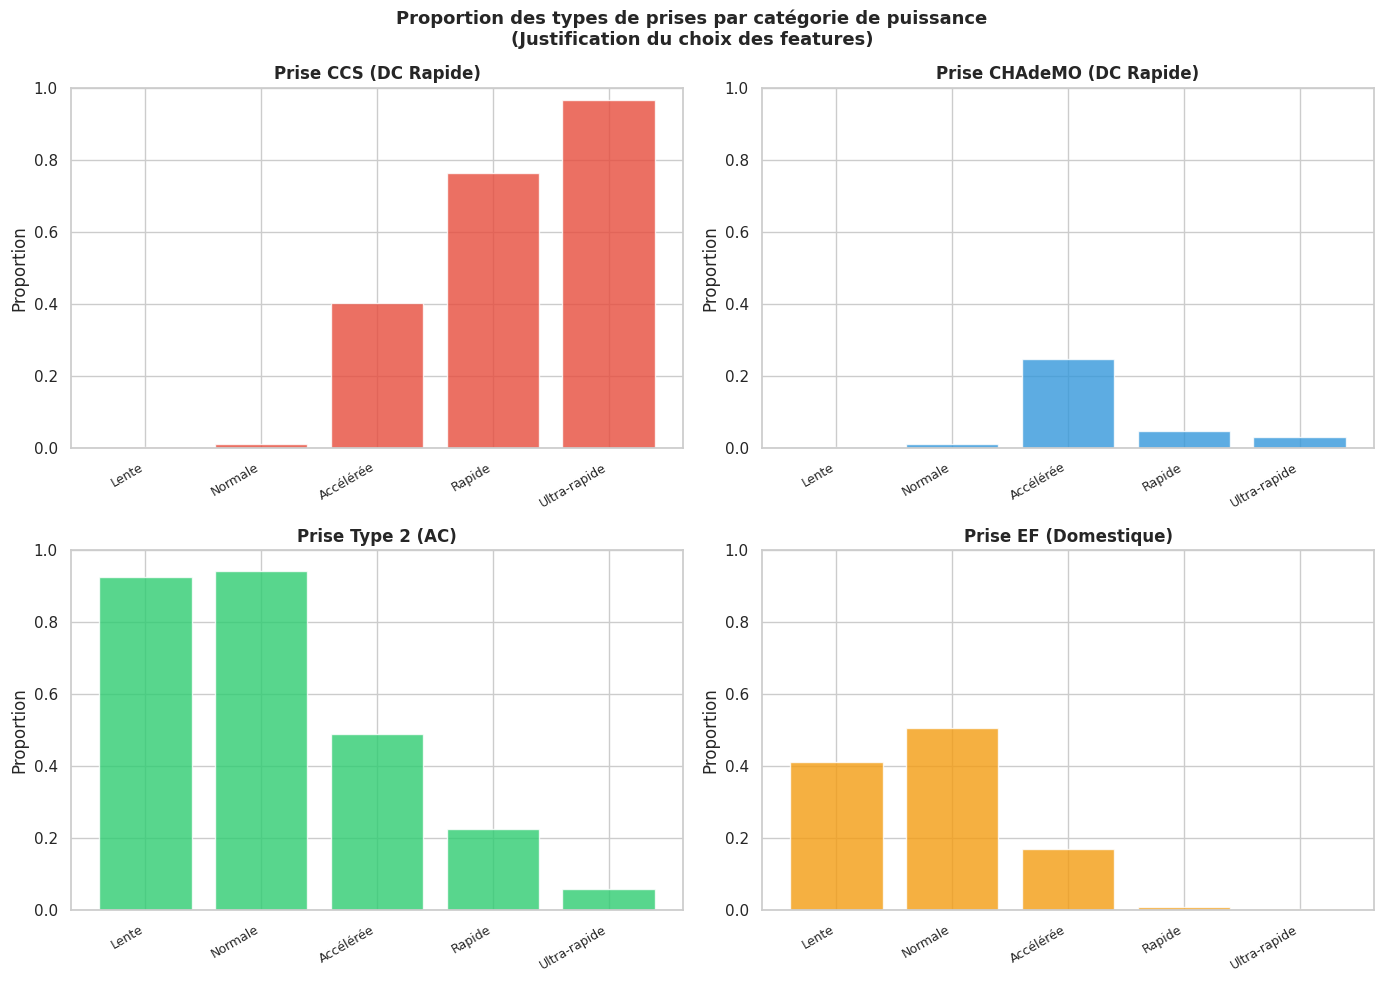

Observation : CCS et CHAdeMO sont fortement corrélés aux bornes rapides/ultra-rapides.
La prise EF est quasi-exclusive aux bornes lentes. Ces patterns valident le choix des features.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Proportion des types de prises par catégorie de puissance\n(Justification du choix des features)',
             fontsize=13, fontweight='bold')

prises = ['prise_ccs', 'prise_chademo', 'prise_type2', 'prise_ef']
couleurs = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
titres = ['Prise CCS (DC Rapide)', 'Prise CHAdeMO (DC Rapide)',
          'Prise Type 2 (AC)', 'Prise EF (Domestique)']

temp = data.copy()

for ax, prise, couleur, titre in zip(axes.flatten(), prises, couleurs, titres):
    proportions = temp.groupby(TARGET)[prise].mean().reindex(ORDRE)
    ax.bar(range(len(ORDRE)), proportions.values, color=couleur, alpha=0.8)
    ax.set_title(titre, fontweight='bold')
    ax.set_xticks(range(len(ORDRE)))
    ax.set_xticklabels(['Lente', 'Normale', 'Accélérée', 'Rapide', 'Ultra-rapide'],
                       rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('output/justification_features_prises_b4.png', dpi=300)
plt.show()
print('Observation : CCS et CHAdeMO sont fortement corrélés aux bornes rapides/ultra-rapides.')
print('La prise EF est quasi-exclusive aux bornes lentes. Ces patterns valident le choix des features.')

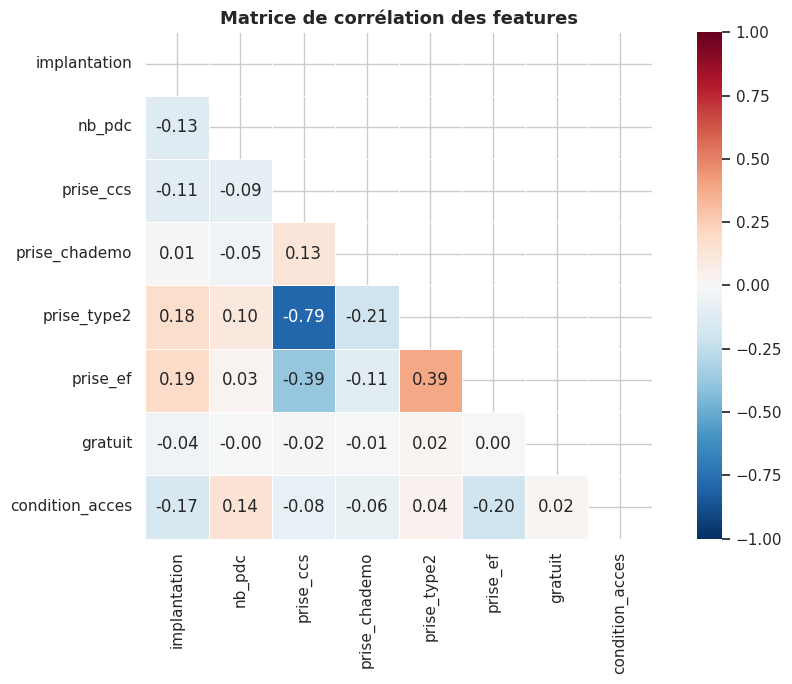

Observation : Pas de forte multicolinéarité entre les features — bon signe pour les modèles linéaires.


In [8]:
plt.figure(figsize=(10, 7))
corr_data = data[FEATURES].copy()
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Matrice de corrélation des features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/correlation_features_b4.png', dpi=300)
plt.show()
print('Observation : Pas de forte multicolinéarité entre les features — bon signe pour les modèles linéaires.')

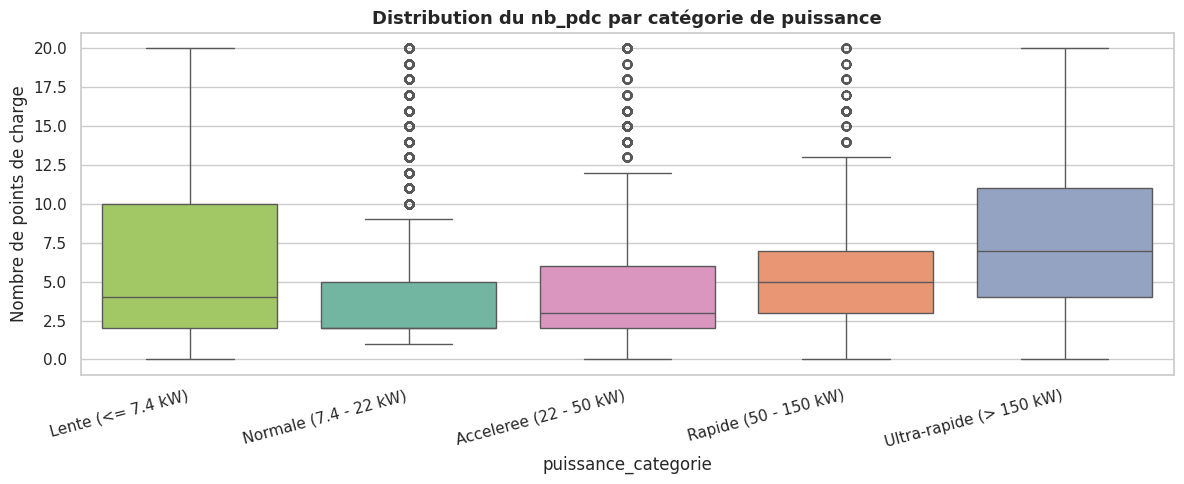

Observation : Les bornes ultra-rapides tendent à avoir plus de PDC par station.


In [9]:
plt.figure(figsize=(12, 5))
data_plot = data[data['nb_pdc'] <= 20]
sns.boxplot(data=data_plot, x=TARGET, y='nb_pdc', order=ORDRE,
            palette='Set2', hue=TARGET, legend=False)
plt.title('Distribution du nb_pdc par catégorie de puissance', fontsize=13, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylabel('Nombre de points de charge')
plt.tight_layout()
plt.savefig('output/boxplot_nbpdc_b4.png', dpi=300)
plt.show()
print('Observation : Les bornes ultra-rapides tendent à avoir plus de PDC par station.')

# 4. Préparation des données pour le Machine Learning

**Justification des paramètres :**
- `test_size=0.2`, `stratify=y` : répartition standard 80/20 qui préserve la proportion de chaque catégorie de puissance dans les deux jeux, important ici car les classes sont déséquilibrées.
- `StandardScaler` : les features sont sur des échelles très différentes (`nb_pdc` numérique vs indicateurs booléens 0/1) — la normalisation évite que les modèles linéaires/distance (Régression Logistique, KNN) ne sur-pondèrent les grandes échelles. Le scaler est ajusté uniquement sur le train pour éviter toute fuite d'information.
- Le scaler et la liste des features sont sauvegardés (`joblib`) pour que `main.py` applique exactement le même prétraitement aux nouvelles données.

In [10]:
X = data[FEATURES].astype(float)
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train : {X_train.shape[0]} échantillons | Test : {X_test.shape[0]} échantillons')
print(f'\nDistribution train :\n{y_train.value_counts()}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, 'scaler_pretraitement_b4.pkl')
joblib.dump(list(FEATURES), 'features_b4.pkl')
print('\nScaler et features sauvegardés.')

Train : 111147 échantillons | Test : 27787 échantillons

Distribution train :
puissance_categorie
Normale (7.4 - 22 kW)      49433
Lente (<= 7.4 kW)          21485
Acceleree (22 - 50 kW)     14946
Ultra-rapide (> 150 kW)    14373
Rapide (50 - 150 kW)       10910
Name: count, dtype: int64

Scaler et features sauvegardés.


# 5. Entraînement et comparaison de plusieurs algorithmes

**Algorithmes comparés :** Régression Logistique, Random Forest, K-Nearest Neighbors, Gradient Boosting.

**Justification du choix des algorithmes :**
- **Régression Logistique** : modèle linéaire (probabilités via softmax), baseline rapide et interprétable.
- **Random Forest** : ensemble d'arbres de décision (bagging), robuste, gère bien les features mixtes et fournit l'importance des variables.
- **K-Nearest Neighbors** : classification non-paramétrique par les k voisins les plus proches, pertinent si les catégories de puissance forment des groupes distincts dans l'espace des features.
- **Gradient Boosting** : ensemble d'arbres en série (boosting), souvent le plus performant sur données tabulaires.

Le cahier des charges demande de tester plusieurs algorithmes et de les comparer — `GridSearchCV` (`cv=3`) optimise les hyperparamètres de chacun avant la comparaison finale.

In [11]:
modeles_config = {
    'Régression Logistique': {
        'modele': LogisticRegression(random_state=RANDOM_STATE, max_iter=500),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'saga']
        }
    },
    'Random Forest': {
        'modele': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'KNN': {
        'modele': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    'Gradient Boosting': {
        'modele': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        }
    }
}

print('Configuration des modèles prête.')
print(f'Nombre de modèles à comparer : {len(modeles_config)}')

Configuration des modèles prête.
Nombre de modèles à comparer : 4


In [12]:
resultats = {}

for nom, config in modeles_config.items():
    print(f'\n--- GridSearchCV : {nom} ---')

    grid = GridSearchCV(
        estimator=config['modele'],
        param_grid=config['params'],
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_scaled, y_train)

    meilleur = grid.best_estimator_
    y_pred = meilleur.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    resultats[nom] = {
        'modele': meilleur,
        'meilleurs_params': grid.best_params_,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'y_pred': y_pred
    }

    print(f'  Meilleurs paramètres : {grid.best_params_}')
    print(f'  Accuracy : {acc:.4f} | F1-macro : {f1_macro:.4f} | F1-weighted : {f1_weighted:.4f}')

print('\n✓ GridSearchCV terminé pour tous les modèles.')


--- GridSearchCV : Régression Logistique ---


  Meilleurs paramètres : {'C': 1.0, 'solver': 'lbfgs'}
  Accuracy : 0.6573 | F1-macro : 0.5242 | F1-weighted : 0.6135

--- GridSearchCV : Random Forest ---


  Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  Accuracy : 0.7728 | F1-macro : 0.7179 | F1-weighted : 0.7683

--- GridSearchCV : KNN ---


  Meilleurs paramètres : {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
  Accuracy : 0.7661 | F1-macro : 0.7133 | F1-weighted : 0.7625

--- GridSearchCV : Gradient Boosting ---


  Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Accuracy : 0.7719 | F1-macro : 0.7169 | F1-weighted : 0.7675

✓ GridSearchCV terminé pour tous les modèles.


# 6. Comparaison et sélection du meilleur modèle

In [13]:
df_resultats = pd.DataFrame({
    'Algorithme': list(resultats.keys()),
    'Accuracy': [r['accuracy'] for r in resultats.values()],
    'F1-Score Macro': [r['f1_macro'] for r in resultats.values()],
    'F1-Score Weighted': [r['f1_weighted'] for r in resultats.values()]
}).sort_values('F1-Score Macro', ascending=False).reset_index(drop=True)

print('=' * 65)
print('       TABLEAU COMPARATIF DES PERFORMANCES')
print('=' * 65)
print(df_resultats.to_string(index=False, float_format='{:.4f}'.format))
print('=' * 65)

meilleur_nom = df_resultats.iloc[0]['Algorithme']
print(f'\n→ Meilleur modèle sélectionné : {meilleur_nom}')

       TABLEAU COMPARATIF DES PERFORMANCES
           Algorithme  Accuracy  F1-Score Macro  F1-Score Weighted
        Random Forest    0.7728          0.7179             0.7683
    Gradient Boosting    0.7719          0.7169             0.7675
                  KNN    0.7661          0.7133             0.7625
Régression Logistique    0.6573          0.5242             0.6135

→ Meilleur modèle sélectionné : Random Forest


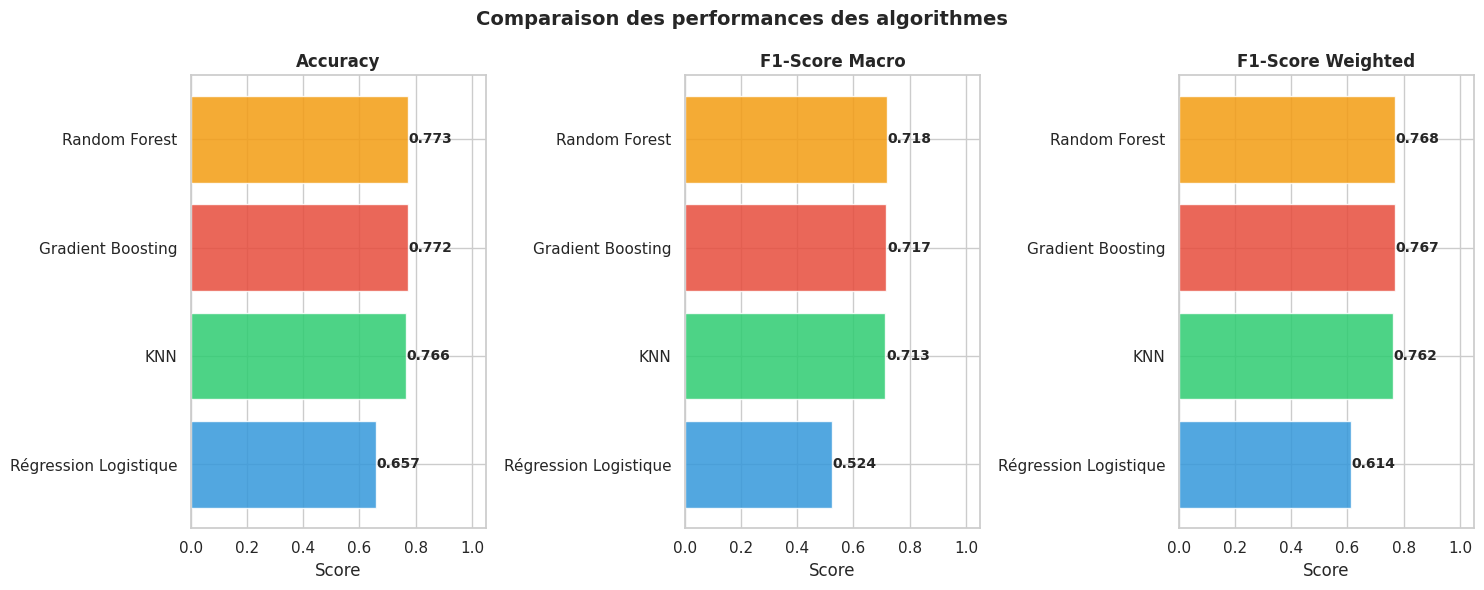

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Comparaison des performances des algorithmes', fontsize=14, fontweight='bold')

metriques = ['Accuracy', 'F1-Score Macro', 'F1-Score Weighted']
couleurs = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for ax, metrique in zip(axes, metriques):
    df_sorted = df_resultats.sort_values(metrique, ascending=True)
    bars = ax.barh(df_sorted['Algorithme'], df_sorted[metrique],
                   color=couleurs[:len(df_sorted)], alpha=0.85)
    for bar, val in zip(bars, df_sorted[metrique]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    ax.set_title(metrique, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Score')

plt.tight_layout()
plt.savefig('output/comparaison_algorithmes_b4.png', dpi=300)
plt.show()

# 7. Évaluation détaillée du meilleur modèle

**Justification du choix des métriques :**
- `classification_report` donne précision, rappel et F1-score par classe — indispensable ici car les classes sont déséquilibrées : l'accuracy globale seule masquerait une mauvaise prédiction sur les classes minoritaires (Rapide, Accélérée).

In [15]:
meilleur_modele = resultats[meilleur_nom]['modele']
y_pred_best = resultats[meilleur_nom]['y_pred']

print(f'RAPPORT D\'ÉVALUATION — {meilleur_nom}')
print('=' * 65)
print(classification_report(y_test, y_pred_best, labels=ORDRE, target_names=ORDRE))

RAPPORT D'ÉVALUATION — Random Forest
                         precision    recall  f1-score   support

      Lente (<= 7.4 kW)       0.81      0.72      0.76      5371
  Normale (7.4 - 22 kW)       0.82      0.90      0.86     12358
 Acceleree (22 - 50 kW)       0.69      0.53      0.60      3737
   Rapide (50 - 150 kW)       0.59      0.59      0.59      2728
Ultra-rapide (> 150 kW)       0.74      0.82      0.78      3593

               accuracy                           0.77     27787
              macro avg       0.73      0.71      0.72     27787
           weighted avg       0.77      0.77      0.77     27787



## 7.1 Matrice de confusion

**Justification :** complète le rapport de classification en visualisant précisément quelles catégories de puissance sont confondues entre elles. Les erreurs se concentrent surtout entre paliers de puissance adjacents (ex. Accélérée confondue avec Normale, Rapide confondue avec Ultra-rapide), ce qui est cohérent avec une variable continue découpée en paliers — les bornes proches d'une frontière de palier sont les plus ambiguës.

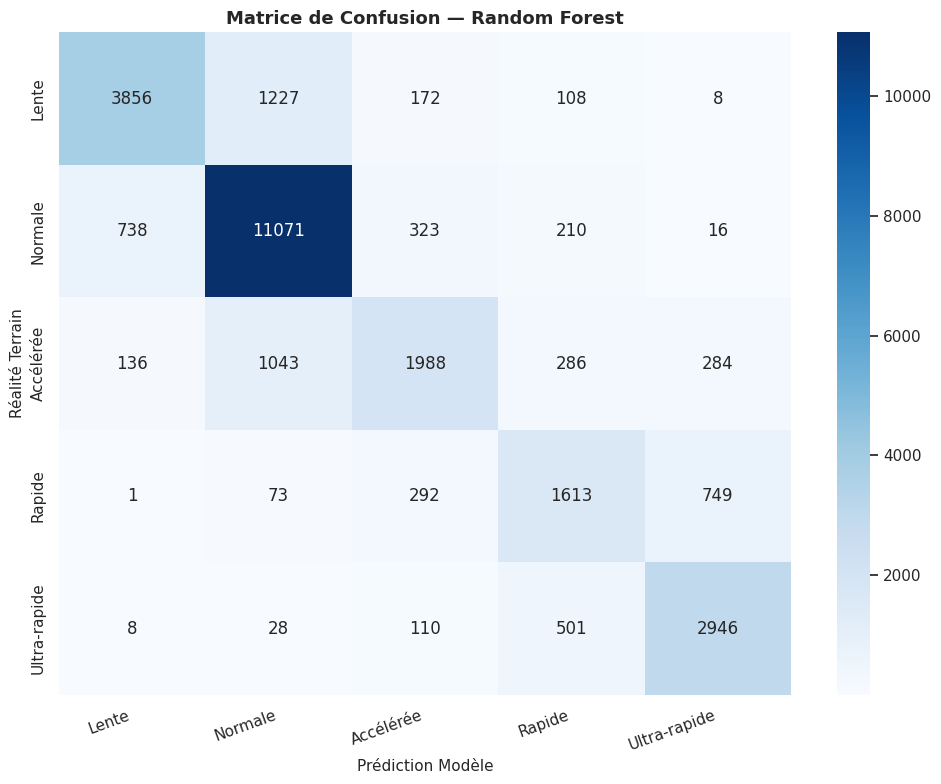

In [16]:
matrice = confusion_matrix(y_test, y_pred_best, labels=ORDRE)
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrice, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Lente', 'Normale', 'Accélérée', 'Rapide', 'Ultra-rapide'],
    yticklabels=['Lente', 'Normale', 'Accélérée', 'Rapide', 'Ultra-rapide']
)
plt.title(f'Matrice de Confusion — {meilleur_nom}', fontsize=13, fontweight='bold')
plt.ylabel('Réalité Terrain', fontsize=11)
plt.xlabel('Prédiction Modèle', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('output/matrice_confusion_b4.png', dpi=300)
plt.show()

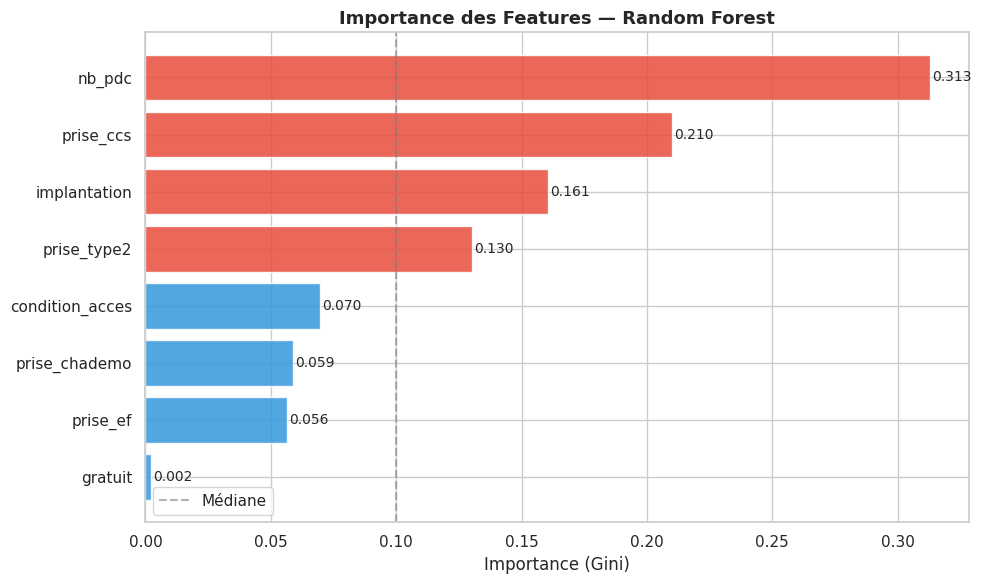

→ Les features les plus importantes confirment les choix faits en section 2.2.


In [17]:
if hasattr(meilleur_modele, 'feature_importances_'):
    importances = meilleur_modele.feature_importances_
    df_imp = pd.DataFrame({
        'Feature': FEATURES,
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    colors = ['#e74c3c' if imp > df_imp['Importance'].median() else '#3498db'
              for imp in df_imp['Importance']]
    bars = plt.barh(df_imp['Feature'], df_imp['Importance'], color=colors, alpha=0.85)
    for bar, val in zip(bars, df_imp['Importance']):
        plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)
    plt.title(f'Importance des Features — {meilleur_nom}',
              fontsize=13, fontweight='bold')
    plt.xlabel('Importance (Gini)')
    plt.axvline(df_imp['Importance'].median(), color='gray',
                linestyle='--', alpha=0.6, label='Médiane')
    plt.legend()
    plt.tight_layout()
    plt.savefig('output/feature_importance_b4.png', dpi=300)
    plt.show()
    print('→ Les features les plus importantes confirment les choix faits en section 2.2.')
else:
    print(f'Importance des features non disponible pour {meilleur_nom}.')
    print('(Disponible pour Random Forest et Gradient Boosting)')

## 7.2 Discussion des résultats

### Analyse par classe
- **Normale (7.4–22 kW)** : classe majoritaire (12 358 bornes sur le test) → recall de 0.90, la mieux prédite.
- **Acceleree (22–50 kW)** et **Rapide (50–150 kW)** : classes les plus minoritaires → recall plus faible (0.53 et 0.59), confondues principalement avec leurs paliers adjacents (Normale et Ultra-rapide respectivement) plutôt qu'entre elles.
- **Ultra-rapide (>150 kW)** : bien identifiée (recall 0.82) grâce aux prises CCS/CHAdeMO comme indicateurs forts.
- **Lente (≤7.4 kW)** : recall 0.72, principalement confondue avec Normale (palier adjacent).

### Limites
- Le **déséquilibre de classes** (12 358 Normale vs 2 728 Rapide) pénalise les classes minoritaires.
- Des techniques comme **SMOTE** ou la pondération des classes pourraient améliorer les résultats.
- L'ajout de features géographiques (département, région) pourrait également aider.

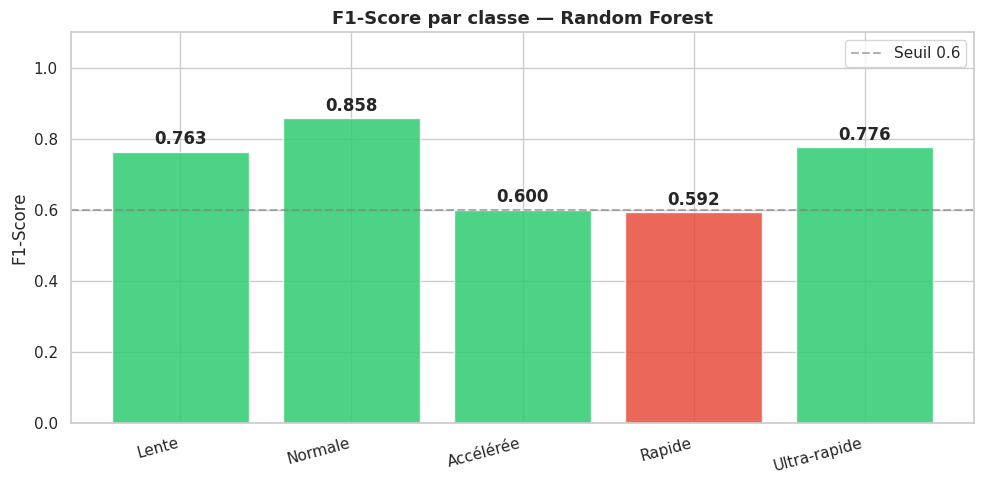

                 Classe  F1-Score
      Lente (<= 7.4 kW)  0.762809
  Normale (7.4 - 22 kW)  0.858217
 Acceleree (22 - 50 kW)  0.600423
   Rapide (50 - 150 kW)  0.592361
Ultra-rapide (> 150 kW)  0.775671


In [18]:
from sklearn.metrics import f1_score as f1_per_class

f1_classes = f1_per_class(y_test, y_pred_best, average=None, labels=ORDRE)
df_f1 = pd.DataFrame({'Classe': ORDRE, 'F1-Score': f1_classes})

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if f > 0.6 else '#e74c3c' for f in f1_classes]
bars = plt.bar(range(len(ORDRE)), f1_classes, color=colors, alpha=0.85)
for bar, val in zip(bars, f1_classes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.axhline(0.6, color='gray', linestyle='--', alpha=0.6, label='Seuil 0.6')
plt.xticks(range(len(ORDRE)), ['Lente', 'Normale', 'Accélérée', 'Rapide', 'Ultra-rapide'],
           rotation=15, ha='right')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
plt.title(f'F1-Score par classe — {meilleur_nom}', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('output/f1_par_classe_b4.png', dpi=300)
plt.show()

print(df_f1.to_string(index=False))

# 8. Sauvegarde du modèle final

In [19]:
joblib.dump(meilleur_modele, 'modele_classification_b4.pkl')
joblib.dump(meilleur_nom, 'nom_meilleur_modele_b4.pkl')

print('Fichiers sauvegardés :')
print('  - modele_classification_b4.pkl  (modèle entraîné)')
print('  - scaler_pretraitement_b4.pkl   (scaler StandardScaler)')
print('  - le_implantation_b4.pkl        (encodeur implantation)')
print('  - le_acces_b4.pkl               (encodeur condition_acces)')
print('  - features_b4.pkl               (liste des features)')
print(f'\nModèle final : {meilleur_nom}')
print(f'Accuracy test : {resultats[meilleur_nom]["accuracy"]:.4f}')
print(f'F1-Score macro : {resultats[meilleur_nom]["f1_macro"]:.4f}')

Fichiers sauvegardés :
  - modele_classification_b4.pkl  (modèle entraîné)
  - scaler_pretraitement_b4.pkl   (scaler StandardScaler)
  - le_implantation_b4.pkl        (encodeur implantation)
  - le_acces_b4.pkl               (encodeur condition_acces)
  - features_b4.pkl               (liste des features)

Modèle final : Random Forest
Accuracy test : 0.7728
F1-Score macro : 0.7179


# 9. Récapitulatif

## Ce qui a été réalisé

1. **Préparation des données** : nettoyage, encodage (LabelEncoder), imputation (médiane), normalisation (StandardScaler). Tous les objets de prétraitement sont sauvegardés en `.pkl`.

2. **Analyse exploratoire** : visualisation de la distribution cible, corrélation features/cible (types de prises), heatmap de corrélation, boxplot nb_pdc.

3. **Comparaison de 4 algorithmes** via GridSearchCV (Régression Logistique, Random Forest, KNN, Gradient Boosting).

4. **Métriques** : Accuracy, F1-score macro, F1-score weighted, rapport de classification complet, matrice de confusion, F1 par classe.

5. **Sauvegarde** du meilleur modèle utilisable par le script `main.py`.

## Conclusion

In [20]:
from IPython.display import Markdown, display

accuracy_pct = resultats[meilleur_nom]['accuracy'] * 100
texte_conclusion = (
    f"Le meilleur modèle obtenu est **{meilleur_nom}** avec une accuracy de "
    f"**{accuracy_pct:.2f}%** sur le jeu de test. La classe majoritaire (Normale) "
    f"est la mieux prédite, et Ultra-rapide est bien identifiée grâce aux "
    f"indicateurs forts que sont les prises CCS/CHAdeMO. Les classes minoritaires "
    f"(Accélérée, Rapide) restent plus difficiles à distinguer, principalement "
    f"confondues avec leur palier de puissance adjacent — une piste d'amélioration "
    f"serait d'utiliser des techniques de rééquilibrage des classes."
)
display(Markdown(texte_conclusion))

Le meilleur modèle obtenu est **Random Forest** avec une accuracy de **77.28%** sur le jeu de test. La classe majoritaire (Normale) est la mieux prédite, et Ultra-rapide est bien identifiée grâce aux indicateurs forts que sont les prises CCS/CHAdeMO. Les classes minoritaires (Accélérée, Rapide) restent plus difficiles à distinguer, principalement confondues avec leur palier de puissance adjacent — une piste d'amélioration serait d'utiliser des techniques de rééquilibrage des classes.